# Desafio Ifood 1 - Curso Estatística Básico ao Avançado | EBA - Renata Biaggi

#### Desafios propostos no módulo de estatística descritiva e no modulo de Teste de Hipotese e IC para variância, teste de associação e ANOVA do curso EBA

### Preparando o ambiente e importando as bibliotecas

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import skew, kurtosis

In [90]:
# Puxando os dados 
df = pd.read_csv("mkt_data.csv")

In [91]:
df.tail(5)

,Unnamed: 0,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,marital_status,education_level,kids,expenses
2200,2200,61223.0,0,1,46,709,43,182,42,118,...,3.0,NaN,NaN,1094,847,0,Married,Graduation,1,1094
2201,2201,64014.0,2,1,56,406,0,30,0,0,...,NaN,NaN,5.0,436,428,1,Together,PhD,3,436
2202,2202,56981.0,0,0,91,908,48,217,32,12,...,3.0,NaN,NaN,1217,1193,1,Divorced,Graduation,0,1217
2203,2203,69245.0,0,1,8,428,30,214,80,30,...,NaN,4.0,NaN,782,721,0,Together,Master,1,782
2204,2204,52869.0,1,1,40,84,3,61,2,1,...,NaN,NaN,5.0,151,130,0,Married,PhD,2,151


##### Q1. Quantos dados temos? Linhas e colunas?


In [ ]:
df.shape

(2205, 44)

##### Q2. Quais são as colunas numéricas?


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            2205 non-null   int64  
 1   Income                2205 non-null   float64
 2   Kidhome               2205 non-null   int64  
 3   Teenhome              2205 non-null   int64  
 4   Recency               2205 non-null   int64  
 5   MntWines              2205 non-null   int64  
 6   MntFruits             2205 non-null   int64  
 7   MntMeatProducts       2205 non-null   int64  
 8   MntFishProducts       2205 non-null   int64  
 9   MntSweetProducts      2205 non-null   int64  
 10  MntGoldProds          2205 non-null   int64  
 11  NumDealsPurchases     2205 non-null   int64  
 12  NumWebPurchases       2205 non-null   int64  
 13  NumCatalogPurchases   2205 non-null   int64  
 14  NumStorePurchases     2205 non-null   int64  
 15  NumWebVisitsMonth    

In [ ]:
df.select_dtypes(include='number').columns

Index(['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall', 'kids', 'expenses'],
      dtype='object')

##### Q3. Temos duplicados na nossa base? Se tivermos, retire-os 


In [7]:
# Temos dados duplicados?
df.duplicated().sum()

np.int64(0)

##### Não temos nenhum dado duplicado em nosso DF

##### Q4. Temos dados nulos nessa base? Será que eles indicam algo? O que fazer com eles? 

In [ ]:
# Pela verificação com .tail(5) já foi possível detectar alguns dados nulls, mas iremos verificar qual a quantidade exata de null e em quais colunas estão presentes
df.isnull().sum()

Unnamed: 0                 0
Income                     0
Kidhome                    0
Teenhome                   0
Recency                    0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
NumDealsPurchases          0
NumWebPurchases            0
NumCatalogPurchases        0
NumStorePurchases          0
NumWebVisitsMonth          0
AcceptedCmp3               0
AcceptedCmp4               0
AcceptedCmp5               0
AcceptedCmp1               0
AcceptedCmp2               0
Complain                   0
Z_CostContact              0
Z_Revenue                  0
Response                   0
Age                        0
Customer_Days              0
marital_Divorced        1975
marital_Married         1351
marital_Single          1728
marital_Together        1637
marital_Widow           2129
education_2n Cycle      2007
education_Basic         2151
education_Grad

In [9]:
# Verificando um único caso para entender como são os dados e qual sua distribuição
df.marital_Divorced.unique().tolist()

[nan, 1.0]

In [ ]:
## Dando a visão que em um dos status tem apenas um número, decidi ampliar a investigação para várias colunas de uma única vez
print(df.marital_Divorced.unique())
print(df.marital_Married.unique())
print(df.marital_Single.unique())
print(df.marital_Together.unique())
print(df.marital_Widow.unique())

[nan  1.]
[nan  5.]
[ 4. nan]
[nan  3.]
[nan  2.]


In [11]:
# Em uma segunda etapa da investigação dos nulls, selecionei as mesmas colunas para fazer uma contagem de dados preenchidos
print(df.marital_Divorced.value_counts())
print(df.marital_Married.value_counts())
print(df.marital_Single.value_counts())
print(df.marital_Together.value_counts())
print(df.marital_Widow.value_counts())

marital_Divorced
1.0    230
Name: count, dtype: int64
marital_Married
5.0    854
Name: count, dtype: int64
marital_Single
4.0    477
Name: count, dtype: int64
marital_Together
3.0    568
Name: count, dtype: int64
marital_Widow
2.0    76
Name: count, dtype: int64


In [12]:
# Fazendo uma verificação a coluna "marital" para entender se os valores de preenchimento das colunas batem com o preenchimento das opções que aparece em "marital_status"
df.marital_status.value_counts()

marital_status
Married     854
Together    568
Single      477
Divorced    230
Widow        76
Name: count, dtype: int64

##### Investigando as colunas que tem valores null, vemos que são, respectivamente:

##### - marital_Divorced
##### - marital_Married
##### - marital_Single
##### - marital_Together
##### - marital_Widow  
##### - education_2n Cycle
##### - education_Basic
##### - education_Graduation
##### - education_Master
##### - education_PhD

##### De acordo com o índice de metadados que determina os dados, temos:
##### - Marital: estado civil do cliente (customer's marital status)
##### - Education: nível de educação (customer's level of education)
##### E pela investigação do preenchimento dos colunas, podemos intuir que as colunas são categorias expandidas de dados qualitativos, ou seja, os valores nulos são esperados. Uma vez que é esperado que cada cliente atenda o requisito apenas de uma das colunas "Marital" e "Education". Para eliminar os valores nulos e tratar os dados de forma mais adequada, transformaremos as colunas em booleanas.

In [95]:
# Selecionando colunas com null
colunas_com_nulos = ["marital_Divorced", "marital_Married", "marital_Single", "marital_Together", "marital_Widow", "education_2n Cycle", "education_Basic", "education_Graduation", "education_Master", "education_PhD"]

In [96]:
## Para tornar todos booleanos, iremos usar um loop simples que irá preencher todo null como "0" e mudar os demais números para 1
for i in colunas_com_nulos:
  df["booleano"+str(i)] = np.where(df[i].isnull(), 0, 1) 

In [97]:
# Verificando de novo o "Tail" do Dataframe, percebemos que os valores foram preenchidos
df.tail(5)

,Unnamed: 0,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,booleanomarital_Divorced,booleanomarital_Married,booleanomarital_Single,booleanomarital_Together,booleanomarital_Widow,booleanoeducation_2n Cycle,booleanoeducation_Basic,booleanoeducation_Graduation,booleanoeducation_Master,booleanoeducation_PhD
2200,2200,61223.0,0,1,46,709,43,182,42,118,...,0,1,0,0,0,0,0,1,0,0
2201,2201,64014.0,2,1,56,406,0,30,0,0,...,0,0,0,1,0,0,0,0,0,1
2202,2202,56981.0,0,0,91,908,48,217,32,12,...,1,0,0,0,0,0,0,1,0,0
2203,2203,69245.0,0,1,8,428,30,214,80,30,...,0,0,0,1,0,0,0,0,1,0
2204,2204,52869.0,1,1,40,84,3,61,2,1,...,0,1,0,0,0,0,0,0,0,1


##### Q5. Qual é a média, mediana, 25 percentil, 75 percentil, mínimo e máximo de cada uma das colunas numéricas? 

In [98]:
df[["kids", "Income", "expenses"]].describe()

,kids,Income,expenses
count,2205.000000,2205.000000,2205.000000
mean,0.948753,51622.094785,562.764626
std,0.749231,20713.063826,575.936911
min,0.000000,1730.000000,4.000000
25%,0.000000,35196.000000,56.000000
50%,1.000000,51287.000000,343.000000
75%,1.000000,68281.000000,964.000000
max,3.000000,113734.000000,2491.000000


### Desafio 1 - Parte II: Perfil do Cliente

##### Q1.Qual é o maior salário encontrado na nossa base? Veja na coluna Income

##### De acordo com a tabela acima, o valor máximo para Income é 113.734

#### Q2. Qual é a distribuição de salário na nossa base? Temos clientes que ganham muito bem e outros que não ganham muito bem? Veja na coluna Income

##### A tabela resumo nos forneceu uma visão inicial da distribuição variada dos salários na base. Para entender melhor a variabilidade, vamos calcular alguns coeficientes que ajudam a entender a dispersão da amostra, além de trazer uma representação gráfica de um histograma e boxplot.

Coeficiente de variação (CV): 40.12
Coeficiente de Assimetria - Skew: 0.01
Curtose: -0.85
Amplitude Geral da Amostra: 112004.0


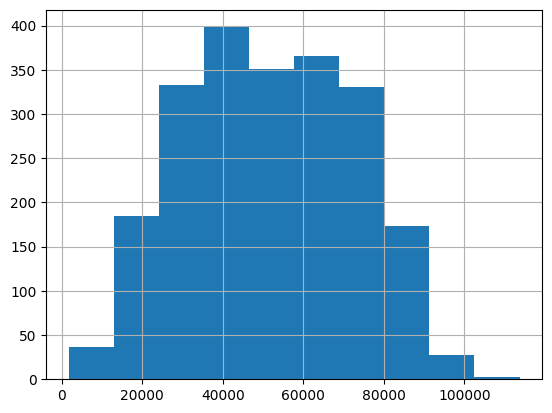

In [99]:
# Entendo como se distribui
df["Income"].hist()

print('Coeficiente de variação (CV):', (df["Income"].std()/df["Income"].mean()).round(4)*100)
print('Coeficiente de Assimetria - Skew:', df['Income'].skew().round(decimals=2))
print('Curtose:', df['Income'].kurtosis().round(decimals=2))
print("Amplitude Geral da Amostra:", df['Income'].max() - df['Income'].min())

<Axes: ylabel='Income'>

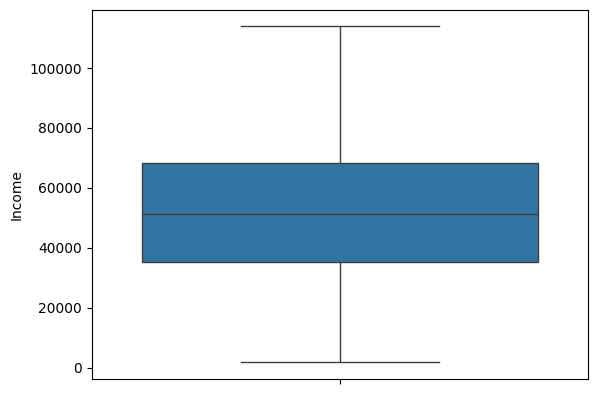

In [100]:
sns.boxplot(df["Income"])

##### Avaliando nossos coeficientes, temos uma variação de 40,12% dos dados da base, com uma assimetria mais notável a direita (skew > 0), ou seja, a distribuição tem um peso a mais em salários mais baixos. E também podemos afirmar que nossos dados tem uma distribuição mais homogênea e sem muitos outliers (curtose < 0), por outro lado, temos uma alta amplitude nos dados da amostra. O que significa que algumas poucas pessoas ganham bem e algumas poucas ganham mal.

#### Q3. Nossos clientes tem níveis de educação maiores ou menores? 

In [19]:
# Entendendo o peso % dos grupos
(df.groupby('education_level',sort=False).education_level.count() / len(df.education_level)).round(4)*100

education_level
Graduation    50.48
PhD           21.59
Master        16.51
Basic          2.45
2n Cycle       8.98
Name: education_level, dtype: float64

#### Entendendo a distribuição gráfica dos dados

<Axes: xlabel='education_level', ylabel='count'>

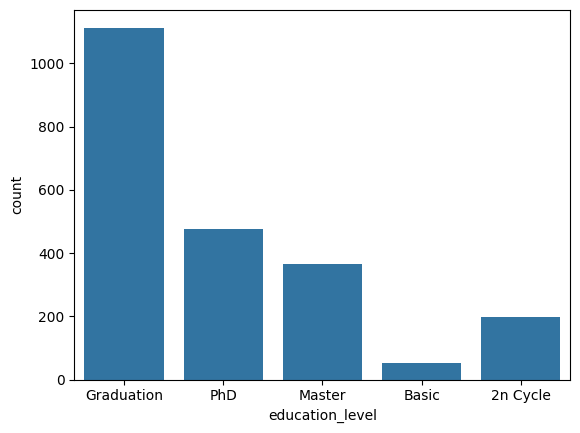

In [20]:
sns.countplot(x=df["education_level"])

##### A maior parte dos clientes de amostra coletada (50,48%) tem graduação completa. Poucos tem apenas a educação básica (2,45%). De modo geral, é possível afirmar que a maioria dos clientes tem educação superior.

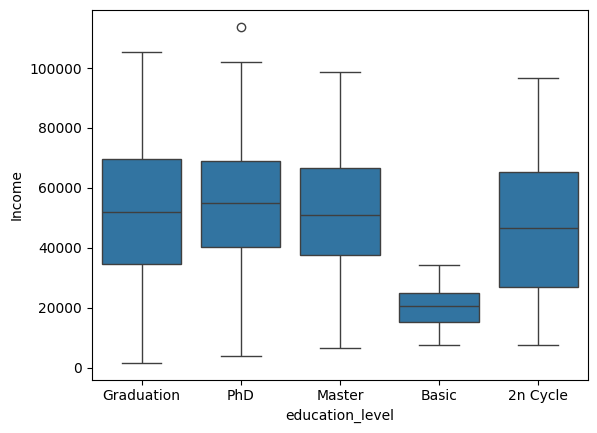

In [67]:
sns.boxplot(data= df, x='education_level', y='Income')
plt.show()

In [63]:
df.groupby('education_level')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
education_level,,,,,,,,
2n Cycle,198.0,47625.333333,22199.278285,7500.0,27113.50,46805.0,65439.75,96547.0
Basic,54.0,20306.259259,6235.066773,7500.0,15405.25,20744.0,24882.00,34445.0
Graduation,1113.0,51984.008086,20918.205185,1730.0,34824.00,51948.0,69755.00,105471.0
Master,364.0,52629.579670,19419.253764,6560.0,37697.25,50920.5,66658.50,98777.0
PhD,476.0,55220.581933,18363.164699,4023.0,40334.00,55005.0,68869.50,113734.0


##### Fazendo uma análise rápida da distribuição de salarial entre os níveis de educação, podemos afirmar que a base segue o padrão de que quanto maior o nível educacional maior a média salarial. 

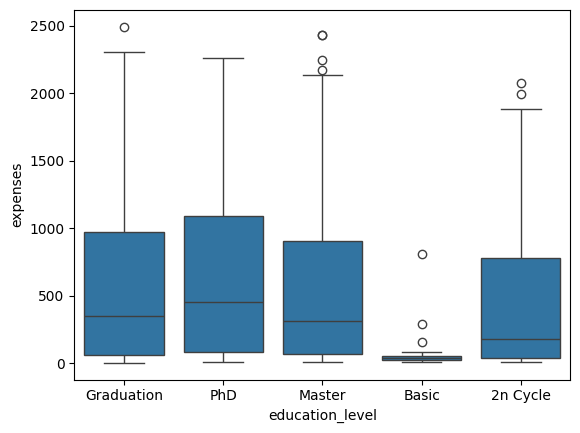

In [68]:
sns.boxplot(data= df, x='education_level', y='expenses')
plt.show()

In [69]:
df.groupby('education_level')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
education_level,,,,,,,,
2n Cycle,198.0,452.272727,510.082273,8.0,43.00,180.0,780.75,2074.0
Basic,54.0,58.962963,111.979439,8.0,21.25,40.0,50.75,809.0
Graduation,1113.0,570.938904,568.994987,4.0,58.00,349.0,970.00,2491.0
Master,364.0,571.002747,602.320831,8.0,68.75,312.0,904.00,2429.0
PhD,476.0,640.466387,595.329564,8.0,86.25,451.5,1089.75,2262.0


In [70]:
# Como foi observado médias parecidas entre o grupo de pessoas da amostra com nível de educação com Graduação e nível com Mestrado tanto no boxplot quanto na tabela resumo, optei por fazer um teste extra e separar os grupos para entender melhor as diferenças
income_graduation = df[df['education_level'] == 'Graduation']['Income']
income_master = df[df['education_level'] == 'Master']['Income']

In [71]:
# Realizando um teste T com 95% de confiança para entender se as médias são estatisticamente iguais de verdade
scipy.stats.ttest_ind(a=income_graduation, b=income_master, equal_var=True)

TtestResult(statistic=np.float64(-0.52004498212603), pvalue=np.float64(0.6031102626900093), df=np.float64(1475.0))

##### Grupos com maior nível educacional não apenas tem a maior presença no Ifood, como também apresentam um gasto médio maior. Destacando-se o grupo com PhD, que registra os maiores gastos entre todos. Comparando os gastos médios entre graduados e mestres, não notamos uma diferença estatisticamente significativa - o que pode ser afirmado tanto pelas médias na tabela descritiva como pelo teste T (p-valor = 0.603).

### Quantos clientes temos em cada estado civil?

In [72]:
# Entendendo o peso % dos grupos
(df.groupby('marital_status',sort=False).education_level.count() / len(df.marital_status)).round(4)*100

marital_status
Single      21.63
Together    25.76
Married     38.73
Divorced    10.43
Widow        3.45
Name: education_level, dtype: float64

<Axes: xlabel='marital_status', ylabel='count'>

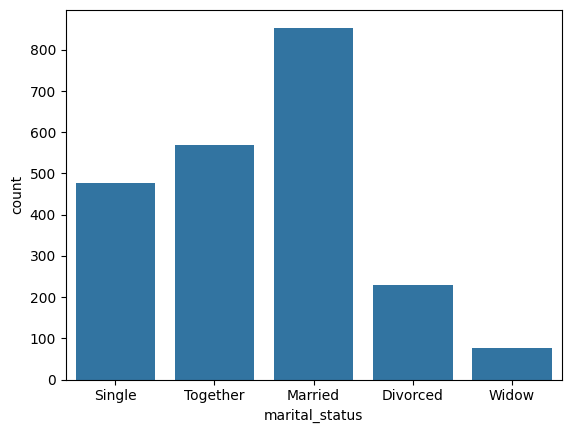

In [73]:
sns.countplot(x=df["marital_status"])

##### Boa parte dos clientes da amostra coletada se declararam como casados (38,73%), em segundo lugar temos pessoas se declarando como "Together" (ou morando junto) (25,76%) e uma minoria se declarou viúvo (3,45%)

In [74]:
df.groupby('marital_status')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
marital_status,,,,,,,,
Divorced,230.0,52465.117391,20227.709969,1730.0,36967.00,52683.0,68625.75,102692.0
Married,854.0,51350.511710,20532.400490,2447.0,35243.75,51650.5,67465.25,96547.0
Single,477.0,51009.622642,22162.839603,3502.0,33812.00,48789.0,68655.00,113734.0
Together,568.0,51553.198944,20358.589548,5648.0,34704.25,51255.0,68143.50,105471.0
Widow,76.0,56481.552632,16837.952451,22123.0,44892.25,56551.0,70321.75,85620.0


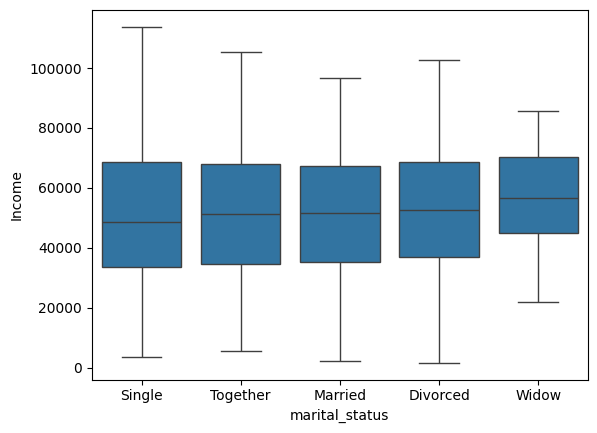

In [75]:
sns.boxplot(data= df, x='marital_status', y='Income')
plt.show()

##### Olhando a distribuição salarial entre os grupos por estado civil, notamos que os grupos de divorciados e viúvos possuem uma renda média maior que os demais grupos. Enquanto, "Single", "Married" e "Together" tem uma renda média parecida.

In [81]:
df.groupby('marital_status')['expenses'].describe()

,count,mean,std,min,25%,50%,75%,max
marital_status,,,,,,,,
Divorced,230.0,569.052174,549.102942,5.0,54.0,361.0,970.25,1959.0
Married,854.0,546.649883,563.821451,8.0,53.0,341.0,917.50,2304.0
Single,477.0,569.274633,607.444750,4.0,59.0,303.0,1023.00,2429.0
Together,568.0,564.350352,581.499890,6.0,55.0,325.0,973.75,2491.0
Widow,76.0,672.105263,545.732207,12.0,122.0,596.0,1035.25,2068.0


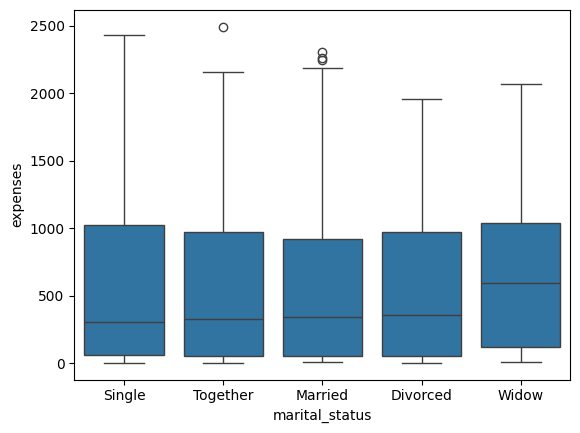

In [82]:
sns.boxplot(data= df, x='marital_status', y='expenses')
plt.show()

In [ ]:
# Como foi observado médias parecidas entre o grupo de pessoas declaradas como "Single" e "Divorced", optei por fazer um teste extra e separar os grupos para entender melhor as diferenças
expenses_single = df[df['marital_status'] == 'Single']['expenses']
expenses_divorced = df[df['marital_status'] == 'Divorced']['expenses']

In [85]:
# Realizando um teste T com 95% de confiança para entender se as médias são estatisticamente iguais de verdade
scipy.stats.ttest_ind(a=expenses_single, b=expenses_divorced, equal_var=True)

TtestResult(statistic=np.float64(0.004703857969356907), pvalue=np.float64(0.9962482088679738), df=np.float64(705.0))

##### Em uma análise rápida dos gastos, podemos notar que o grupo "Widow (viúvos)" tem o maior gasto médio, mas é o menor grupo da amostra (apenas 3,45% dos usuários). "Single" (solteiros) e "Divorced" (divorciados) tem o segundo maior gasto médio, com uma diferença não signifitiva entre as médias (Test T - p-valor 0.9962). Juntos, representam 32% da amostra, sendo um grupo potencialmente interessante de ser explorado em estratégias.